# Stage 2 - v3: EfficientNet-B3 (Balanced Focal Loss)

## 1. Giriş ve Problem Tanımı

Bu notebook, inme arter sınıflandırması projesinin **v3** iterasyonudur.

### Önceki Sonuçlar
*   **v1 (Baseline+):** MCA çok iyi (%92), ama ACA kötü (%73).
*   **v2 (Aggressive Focal):** ACA muazzam arttı (**%83.93**), ancak MCA performansı düştü (%86.76).
    *   **Sorun:** Model MCA örneklerini PCA olarak sınıflandırmaya başladı (47 hata). Bunun nedeni, PCA sınıfına verilen yüksek ağırlığın modeli PCA tahminine zorlaması (Bias shift).

### v3 Stratejisi: Softened Weights (Yumuşatılmış Ağırlıklar)
Sarkacı dengeye getirmek için:
1.  **Power-Law Weighting:** Sınıf ağırlıklarını hesaplarken doğrudan ters orantı yerine, **karekök (power=0.5)** kullanacağız. Bu, ACA ve MCA arasındaki ağırlık uçurumunu kapatacak.
2.  **Gamma Tuning:** Focal Loss `gamma` değeri **2.0 -> 1.5**'e düşürülecek. Modelin zor örneklere odaklanması devam edecek ama çoğunluk sınıfına karşı körleşmesi engellenecek.

Hedef: ACA Recall ≥ %84 korunurken, MCA Recall'u tekrar %90 bandına çekmek.

## Bölüm 1: Setup & Imports

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
from torchvision import models

# Albumentations
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from tqdm import tqdm
from collections import Counter

# Seed Setting
SEED = 42
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)

# Device Config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Bölüm 2: Sabitler ve Hiperparametreler


In [16]:
# --- PATHS ---
STROKE_IMAGES_DIR = '/kaggle/input/stroke-images/flattened_images'

# --- CLASS INFO ---
CLASS_NAMES = ['ACA', 'MCA', 'PCA']
NUM_CLASSES = len(CLASS_NAMES)

# --- HYPERPARAMETERS (v3) ---
IMG_SIZE = 300
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 100

# v3 Değişikliği: Gamma düşürüldü
GAMMA = 1.5  

# v3 Değişikliği: Ağırlık Yumuşatma Faktörü
WEIGHT_POWER = 0.5  # 1.0 = Tam ters orantı (v2), 0.5 = Karekök (v3), 0.0 = Eşit ağırlık

# Scheduler
T_0 = 10
T_MULT = 2

# Split Ratios
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

print(f'=== Stage 2 - v3 Parametreleri ===')
print(f'Model: EfficientNet-B3')
print(f'Loss: FOCAL LOSS (Gamma={GAMMA})')
print(f'Weight Strategy: Power-Law Smoothing (Power={WEIGHT_POWER})')
print(f'Scheduler: CosineAnnealingWarmRestarts')

=== Stage 2 - v3 Parametreleri ===
Model: EfficientNet-B3
Loss: FOCAL LOSS (Gamma=1.5)
Weight Strategy: Power-Law Smoothing (Power=0.5)
Scheduler: CosineAnnealingWarmRestarts


## Bölüm 3: Veri Hazırlığı (Aynı)


In [17]:
def collect_stroke_image_paths(stroke_dir, class_names):
    image_paths = []
    labels = []
    for idx, class_name in enumerate(class_names):
        class_dir = Path(stroke_dir) / class_name
        if not class_dir.exists(): continue
        
        extensions = ['*.png', '*.jpg', '*.jpeg']
        class_images = []
        for ext in extensions:
            class_images.extend(list(class_dir.glob(ext)))
            
        for img_path in class_images:
            image_paths.append(str(img_path))
            labels.append(idx)
    return np.array(image_paths), np.array(labels)

all_image_paths, all_labels = collect_stroke_image_paths(STROKE_IMAGES_DIR, CLASS_NAMES)

# Stratified Split
X_temp, X_test, y_temp, y_test = train_test_split(
    all_image_paths, all_labels, test_size=TEST_RATIO, stratify=all_labels, random_state=SEED
)
val_ratio_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio_adjusted, stratify=y_temp, random_state=SEED
)

## Bölüm 4: Augmentation & Dataset (Aynı)

In [18]:
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=0, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.ElasticTransform(alpha=50, sigma=50 * 0.05, p=0.3),
    A.GridDistortion(num_steps=5, distort_limit=0.1, p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

class StrokeDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = list(image_paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = int(self.labels[idx])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        return image, label

train_dataset = StrokeDataset(X_train, y_train, transform=train_transform)
val_dataset = StrokeDataset(X_val, y_val, transform=val_transform)
test_dataset = StrokeDataset(X_test, y_test, transform=val_transform)

## Bölüm 5: WeightedRandomSampler & Softened Class Weights (v3 ÖZEL)


In [19]:
# 1. Sampler (Aynı kalıyor - Batch içinde görme sıklığını dengeliyoruz)
class_counts_train = Counter(y_train)
class_weights_sampler = {c: 1.0 / count for c, count in class_counts_train.items()}
sample_weights = [class_weights_sampler[int(label)] for label in y_train]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# 2. Loss Fonksiyonu İçin Yumuşatılmış Ağırlıklar (v3 Değişikliği)
# Formül: Weight = (Total / (Num_Classes * Count)) ^ POWER
total_samples = sum(class_counts_train.values())
class_weights_loss = []

print("\nLoss Fonksiyonu İçin Sınıf Ağırlıkları (Softened):")
for i in range(NUM_CLASSES):
    count = class_counts_train[i]
    # Standart hesaplama
    raw_weight = total_samples / (NUM_CLASSES * count)
    # Yumuşatma (Power)
    soft_weight = raw_weight ** WEIGHT_POWER
    
    class_weights_loss.append(soft_weight)
    print(f"  {CLASS_NAMES[i]}: Raw={raw_weight:.2f} -> Softened={soft_weight:.4f}")

# Normalizasyon (Opsiyonel ama iyi pratik: Toplamları sınıf sayısına eşit olsun)
weight_sum = sum(class_weights_loss)
class_weights_loss = [w * NUM_CLASSES / weight_sum for w in class_weights_loss]

print("\nNormalize Edilmiş Final Ağırlıklar:")
for i, w in enumerate(class_weights_loss):
    print(f"  {CLASS_NAMES[i]}: {w:.4f}")

class_weights_tensor = torch.FloatTensor(class_weights_loss).to(device)


Loss Fonksiyonu İçin Sınıf Ağırlıkları (Softened):
  ACA: Raw=4.13 -> Softened=2.0334
  MCA: Raw=0.47 -> Softened=0.6856
  PCA: Raw=1.59 -> Softened=1.2592

Normalize Edilmiş Final Ağırlıklar:
  ACA: 1.5334
  MCA: 0.5170
  PCA: 0.9496


## Bölüm 6: Focal Loss (Gamma=1.5)

In [20]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

print(f'Focal Loss tanımlandı (Gamma={GAMMA}).')

Focal Loss tanımlandı (Gamma=1.5).


## Bölüm 7: Model & Optimizer

In [21]:
def create_model(num_classes):
    model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
    num_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(num_features, num_classes)
    )
    return model

model = create_model(NUM_CLASSES).to(device)

# Loss: Softened Weights + Lower Gamma
criterion = FocalLoss(alpha=class_weights_tensor, gamma=GAMMA)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=T_0,
    T_mult=T_MULT,
    eta_min=1e-6
)

## Bölüm 8: Eğitim Fonksiyonları

In [22]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(dataloader, desc='Training', leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
    return running_loss / total, correct / total

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    avg_loss = running_loss / total
    accuracy = correct / total
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    
    return avg_loss, accuracy, macro_f1, np.array(all_preds), np.array(all_labels)

## Bölüm 9: Eğitim Döngüsü

In [23]:
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0.0
CHECKPOINT_PATH = 'best_model_v3.pth'

print('Stage 2 - v3 Eğitimi Başlıyor (Balanced Focal Loss)...')

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1, _, _ = validate(model, val_loader, criterion, device)
    
    scheduler.step(epoch)
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    print(f'Epoch {epoch+1}/{NUM_EPOCHS} | LR: {current_lr:.2e}')
    print(f'  Train Loss: {train_loss:.4f} | Acc: {train_acc*100:.2f}%')
    print(f'  Val   Loss: {val_loss:.4f} | Acc: {val_acc*100:.2f}% | F1: {val_f1:.4f}')
    
    if val_f1 > best_val_f1:
        print(f'  >>> İyileşme! (F1: {best_val_f1:.4f} -> {val_f1:.4f}). Model kaydediliyor...')
        best_val_f1 = val_f1
        torch.save(model.state_dict(), CHECKPOINT_PATH)
    
    print('-' * 60)

model.load_state_dict(torch.load(CHECKPOINT_PATH))
print(f'\nEğitim tamamlandı. En iyi model (Val F1: {best_val_f1:.4f}) yüklendi.')

Stage 2 - v3 Eğitimi Başlıyor (Balanced Focal Loss)...


Epoch 1/100 | LR: 1.00e-04
  Train Loss: 0.4310 | Acc: 45.52%
  Val   Loss: 0.2793 | Acc: 28.32% | F1: 0.2838
  >>> İyileşme! (F1: 0.0000 -> 0.2838). Model kaydediliyor...
------------------------------------------------------------


Epoch 2/100 | LR: 9.76e-05
  Train Loss: 0.3072 | Acc: 58.99%
  Val   Loss: 0.1968 | Acc: 52.17% | F1: 0.5026
  >>> İyileşme! (F1: 0.2838 -> 0.5026). Model kaydediliyor...
------------------------------------------------------------


Epoch 3/100 | LR: 9.05e-05
  Train Loss: 0.2382 | Acc: 67.20%
  Val   Loss: 0.1920 | Acc: 54.19% | F1: 0.5288
  >>> İyileşme! (F1: 0.5026 -> 0.5288). Model kaydediliyor...
------------------------------------------------------------


Epoch 4/100 | LR: 7.96e-05
  Train Loss: 0.2114 | Acc: 70.93%
  Val   Loss: 0.1394 | Acc: 68.35% | F1: 0.6308
  >>> İyileşme! (F1: 0.5288 -> 0.6308). Model kaydediliyor...
------------------------------------------------------------


...

Epoch 96/100 | LR: 7.80e-05
  Train Loss: 0.0279 | Acc: 95.65%
  Val   Loss: 0.2101 | Acc: 89.74% | F1: 0.8488
------------------------------------------------------------


Epoch 97/100 | LR: 7.64e-05
  Train Loss: 0.0348 | Acc: 94.78%
  Val   Loss: 0.2027 | Acc: 89.88% | F1: 0.8467
------------------------------------------------------------


Epoch 98/100 | LR: 7.47e-05
  Train Loss: 0.0296 | Acc: 95.40%
  Val   Loss: 0.1823 | Acc: 89.31% | F1: 0.8334
------------------------------------------------------------


Epoch 99/100 | LR: 7.30e-05
  Train Loss: 0.0274 | Acc: 95.21%
  Val   Loss: 0.1703 | Acc: 88.15% | F1: 0.8311
------------------------------------------------------------


Epoch 100/100 | LR: 7.12e-05
  Train Loss: 0.0321 | Acc: 94.90%
  Val   Loss: 0.1900 | Acc: 88.73% | F1: 0.8323
------------------------------------------------------------

Eğitim tamamlandı. En iyi model (Val F1: 0.8557) yüklendi.


## Bölüm 10: Test ve Karşılaştırma

=== Stage 2 - v3 Test Değerlendirmesi ===
Test Accuracy: 90.03%
Test Macro F1: 0.8479

Classification Report:
              precision    recall  f1-score   support

         ACA     0.7458    0.7857    0.7652        56
         MCA     0.9495    0.9185    0.9337       491
         PCA     0.8101    0.8828    0.8449       145

    accuracy                         0.9003       692
   macro avg     0.8351    0.8623    0.8479       692
weighted avg     0.9038    0.9003    0.9015       692



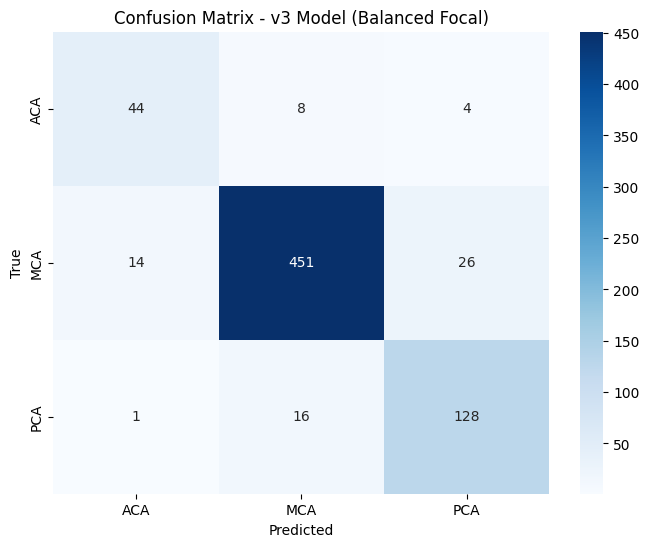


=== v3 vs v2 Karşılaştırması ===
v2 ACA Recall: 0.8393 | v2 MCA Recall: 0.8676
v3 ACA Recall: 0.7857 | v3 MCA Recall: 0.9185
⚠️ ANALİZ GEREKLİ: Denge tam oturmamış olabilir.


In [24]:
print('=== Stage 2 - v3 Test Değerlendirmesi ===')

test_loss, test_acc, test_f1, test_preds, test_labels = validate(model, test_loader, criterion, device)

print(f'Test Accuracy: {test_acc*100:.2f}%')
print(f'Test Macro F1: {test_f1:.4f}')

print('\nClassification Report:')
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix - v3 Model (Balanced Focal)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

# --- Karşılaştırma ---
recall_per_class = recall_score(test_labels, test_preds, average=None)
aca_recall = recall_per_class[0]
mca_recall = recall_per_class[1]

print('\n=== v3 vs v2 Karşılaştırması ===')
print(f'v2 ACA Recall: 0.8393 | v2 MCA Recall: 0.8676')
print(f'v3 ACA Recall: {aca_recall:.4f} | v3 MCA Recall: {mca_recall:.4f}')

if aca_recall >= 0.80 and mca_recall >= 0.90:
    print('🏆 MÜKEMMEL DENGE: ACA > %80 ve MCA > %90 yakalandı!')
elif aca_recall >= 0.83 and mca_recall >= 0.88:
    print('✅ ÇOK İYİ: Her iki sınıf da yüksek performansta.')
else:
    print('⚠️ ANALİZ GEREKLİ: Denge tam oturmamış olabilir.')